# Phase 5A Contextual-Expectation Feasibility

This executed notebook presents the frozen v1.0 outputs produced by `src/phase5a_contextual_expectation_feasibility.py`. It does not refit models. The primary result is category **A**, with B4 selected as the lowest-MAE simple level; only B0→B1 passes adjacent materiality.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'outputs' / 'phase5a'
FIG = ROOT / 'figures' / 'phase5a'
classification = json.loads((OUT / 'classification.json').read_text())
classification

{'primary': {'category': 'A',
  'best_simple_model': 'B4',
  'A_qualifying_models': ['B1', 'B2', 'B3', 'B4'],
  'classification_precedence': ['A', 'C', 'B']},
 'sensitivity': {'category': 'A',
  'best_simple_model': 'B4',
  'A_qualifying_models': ['B1', 'B2', 'B3', 'B4'],
  'classification_precedence': ['A', 'C', 'B']},
 'maximum_claim_if_A': 'Future focal-relative path contains reproducibly predictable structure from pre-interval observable context.',
 'nonclaims_preserved': True}

## Support and leakage

In [2]:
attrition = pd.read_csv(OUT / 'primary_attrition.csv')
display(attrition[attrition['defending_team_id'].eq('ALL')])
display(pd.read_csv(OUT / 'leakage_audit.csv'))
json.loads((OUT / 'target_reproduction_audit.json').read_text())

,match_id,defending_team_id,phase4_eligible_focal_observations,history_complete_focal_observations,ball_history_complete_focal_observations,B4_complete_focal_observations,final_common_comparison_observations,B4_retention_percentage
14,J03WMX,ALL,6949,6948,6948,6948,6948,99.985609
15,J03WN1,ALL,5436,5436,5436,5436,5436,100.000000
16,J03WOH,ALL,6116,6115,6115,6115,6115,99.983649
17,J03WOY,ALL,6345,6342,6342,6342,6342,99.952719
18,J03WPY,ALL,7077,7074,7074,7074,7074,99.957609
19,J03WQQ,ALL,6298,6296,6296,6296,6296,99.968244
20,J03WR9,ALL,6558,6556,6556,6556,6556,99.969503
21,ALL,ALL,44779,44767,44767,44767,44767,99.973202


,history,observations,feature_at_or_before_cutoff,cutoff_before_target_raw_support,one_frame_gap,target_125_119_118,history_counts,minimum_reference_count,target_and_history_membership_stored_separately,future_eligibility_predictor,future_substitution_membership,centered_predictor_smoothing,interpolation,identity_predictors,passed
0,2s,44767,True,True,True,True,True,True,True,False,False,False,False,False,True
1,1s,44769,True,True,True,True,True,True,True,False,False,False,False,False,True


{'phase5a_common_observations': 44767,
 'matched_phase4c_observations': 44767,
 'maximum_absolute_target_difference_m': 1.2816414596272807e-12,
 'passed': True}

## Frozen model ladder

,model,median_MAE,MAE_min,MAE_max,MAE_IQR,median_relative_improvement_vs_B0,matches_improved_vs_B0,matches_worsened_10pct_or_more_vs_B0
0,B0,2.665929,2.491365,2.803410,0.065912,0.000000,0,0
1,B1,2.165298,2.028743,2.279547,0.029937,0.186383,7,0
2,B2,2.128902,1.940814,2.249630,0.039340,0.200899,7,0
3,B3,2.119231,1.926349,2.237786,0.033369,0.205404,7,0
4,B4,2.113946,1.918203,2.232669,0.034381,0.205794,7,0


,prior,current,median_relative_MAE_improvement,matches_improved,matches_worsened_10pct_or_more,materiality_pass
0,B0,B1,0.186383,7,0,True
1,B1,B2,0.017841,7,0,False
2,B2,B3,0.007453,7,0,False
3,B3,B4,0.002494,7,0,False


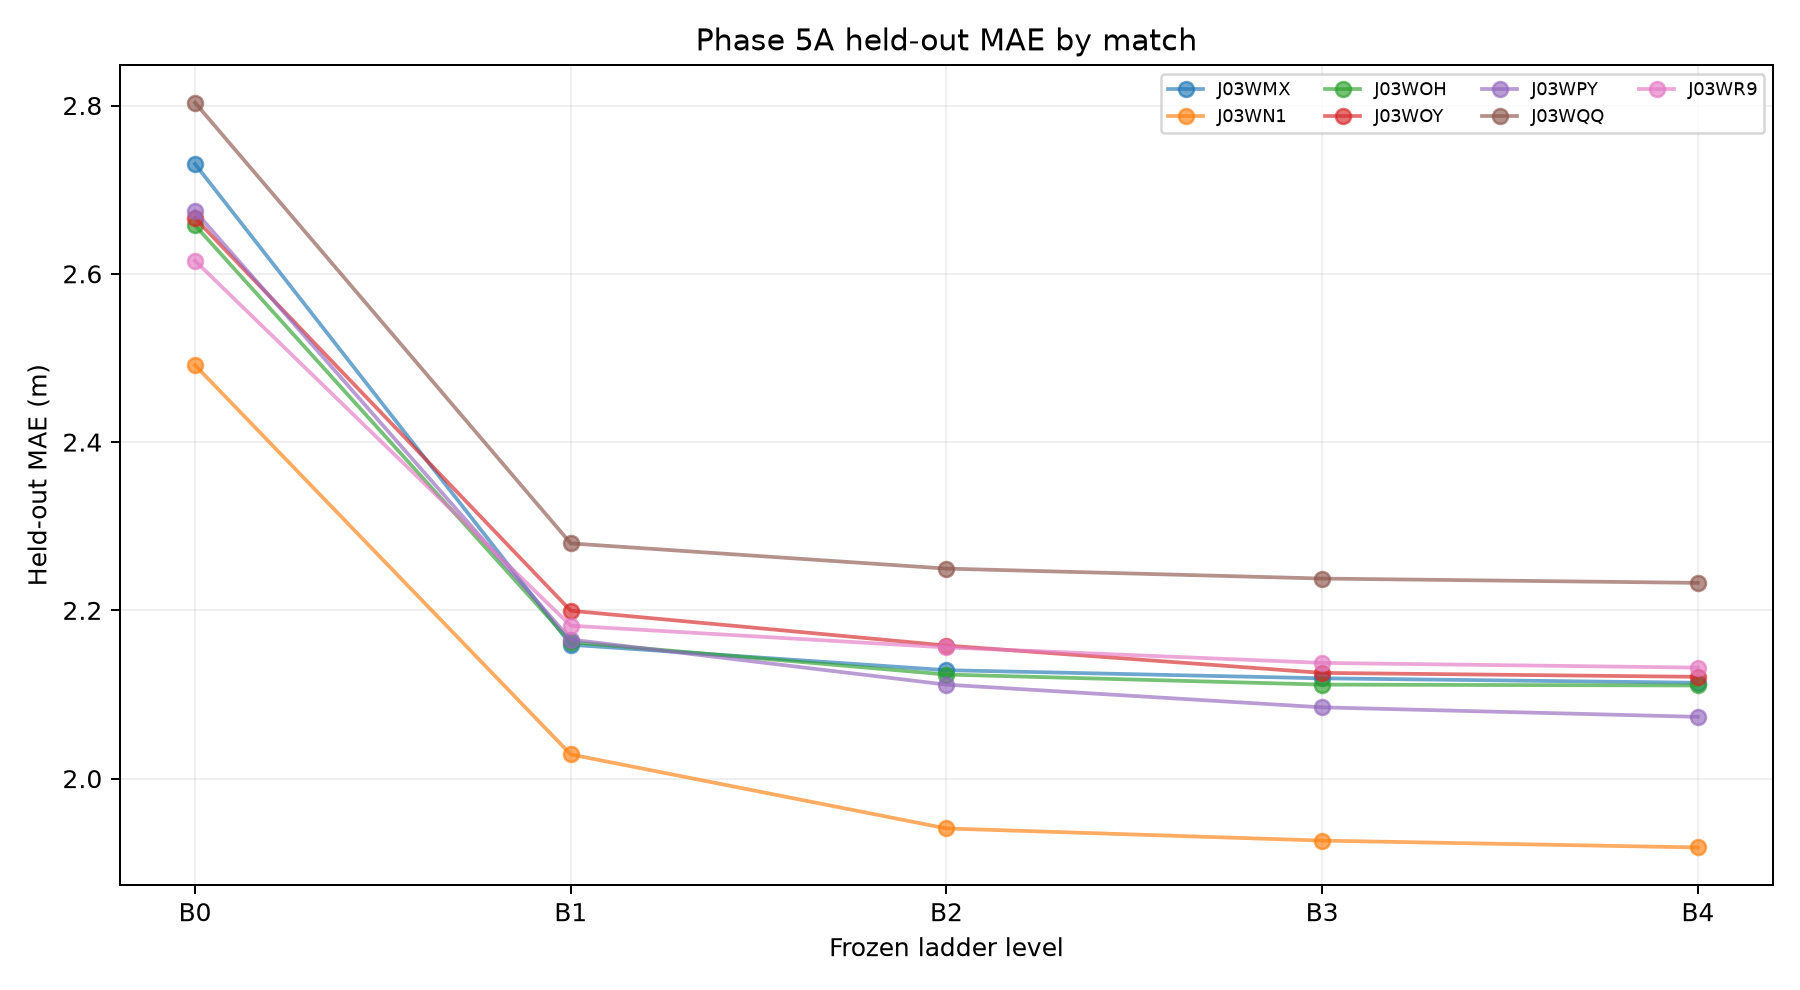

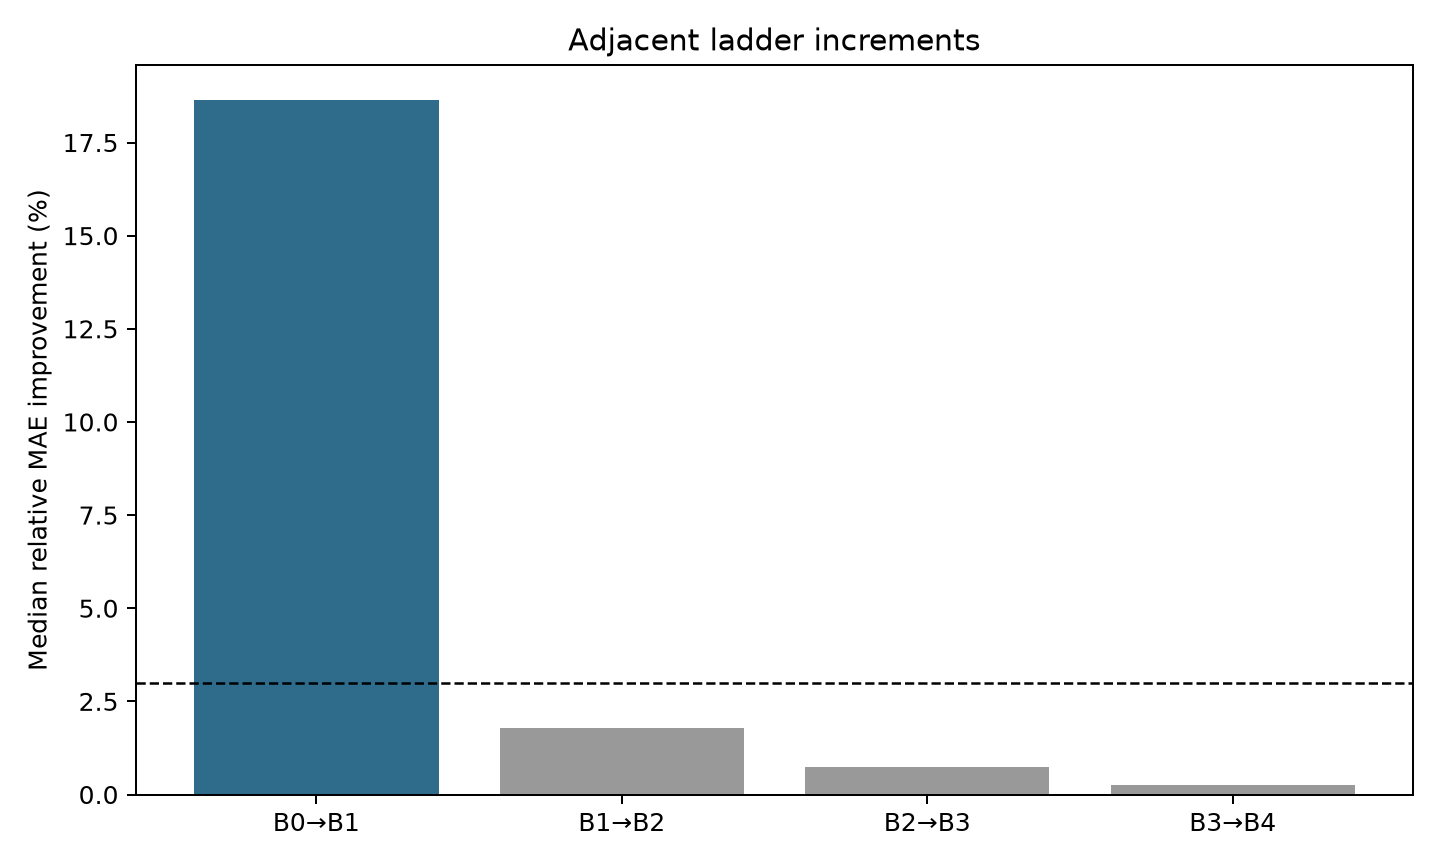

In [3]:
primary = pd.read_csv(OUT / 'primary_model_summary.csv')
adjacent = pd.read_csv(OUT / 'primary_adjacent_materiality.csv')
display(primary)
display(adjacent)
display(Image(filename=str(FIG / 'heldout_mae_by_match.png')))
display(Image(filename=str(FIG / 'adjacent_improvement.png')))

## Calibration and residual diagnostics

,history,outer_heldout_match,model,bin,realized_bins,lower_edge,upper_edge,n,predicted_mean,predicted_median,observed_mean,observed_median,calibration_slope,calibration_intercept
23,2s,J03WMX,B4,ALL,5,NaN,NaN,6948,5.932073,5.674892,5.945140,5.141782,1.031858,-0.175916
47,2s,J03WN1,B4,ALL,5,NaN,NaN,5436,5.378557,4.921355,5.244495,4.424796,1.084206,-0.586970
71,2s,J03WOH,B4,ALL,5,NaN,NaN,6115,5.721182,5.418718,5.746851,4.934585,0.998134,0.036343
95,2s,J03WOY,B4,ALL,5,NaN,NaN,6342,5.784457,5.440868,5.808867,4.930497,0.881925,0.707412
119,2s,J03WPY,B4,ALL,5,NaN,NaN,7074,5.654671,5.323574,5.622950,4.769820,1.036017,-0.235386
143,2s,J03WQQ,B4,ALL,5,NaN,NaN,6296,6.007780,5.708283,6.067066,5.229200,0.998711,0.067030
167,2s,J03WR9,B4,ALL,5,NaN,NaN,6556,5.903624,5.522687,5.923700,5.149043,0.972915,0.179973


,scope,group,variable,spearman_rho,n
0,overall,ALL,focal_recent_absolute_path_m,0.014422,44767
8,overall,ALL,loo_centroid_recent_path_m,-0.014844,44767
16,overall,ALL,other_defenders_recent_mean_path_m,-0.021856,44767
24,overall,ALL,ball_recent_path_m,-0.020978,44767
32,overall,ALL,focal_own_goal_depth_m,0.001588,44767
40,overall,ALL,focal_lateral_distance_m,-0.009225,44767
48,overall,ALL,predicted,0.002541,44767


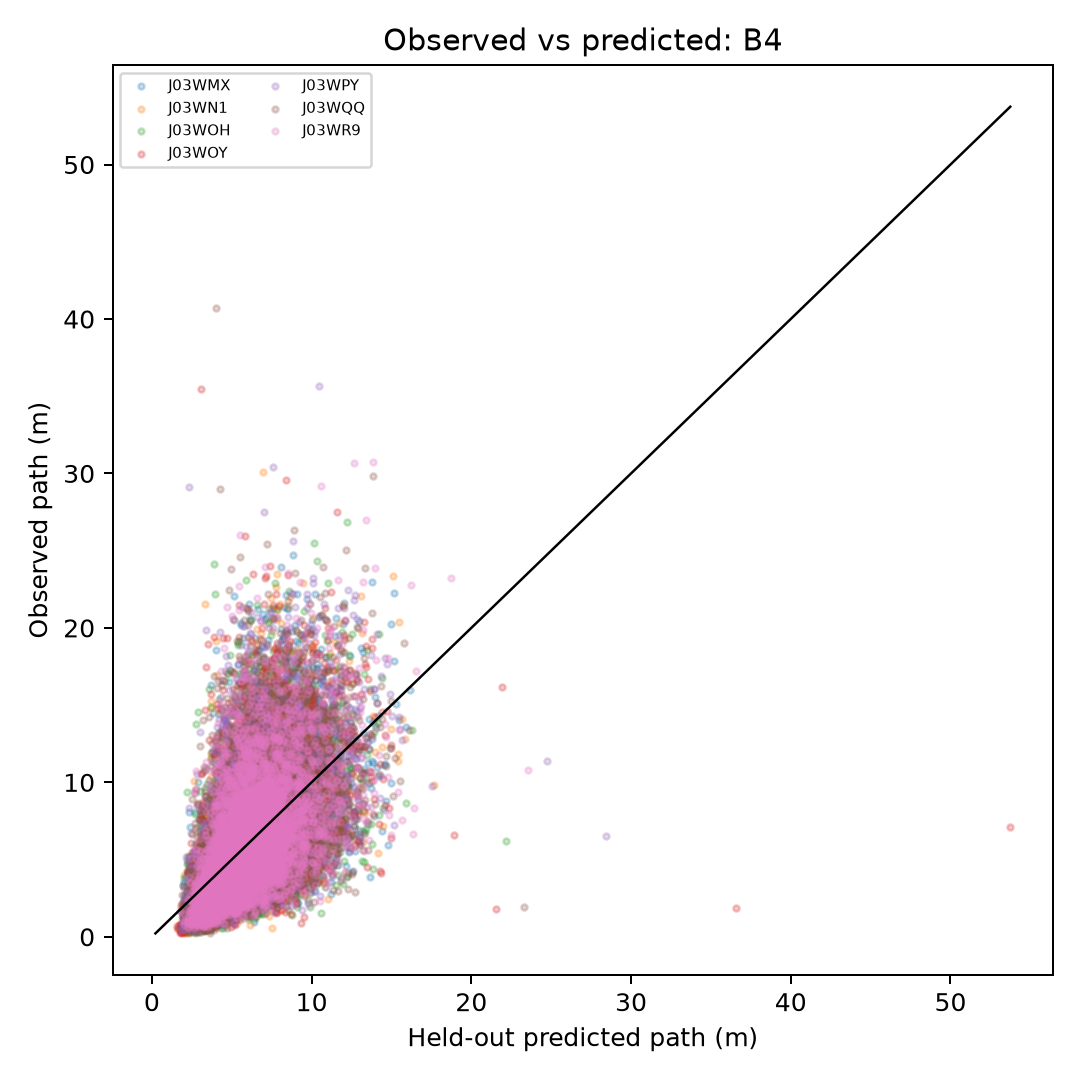

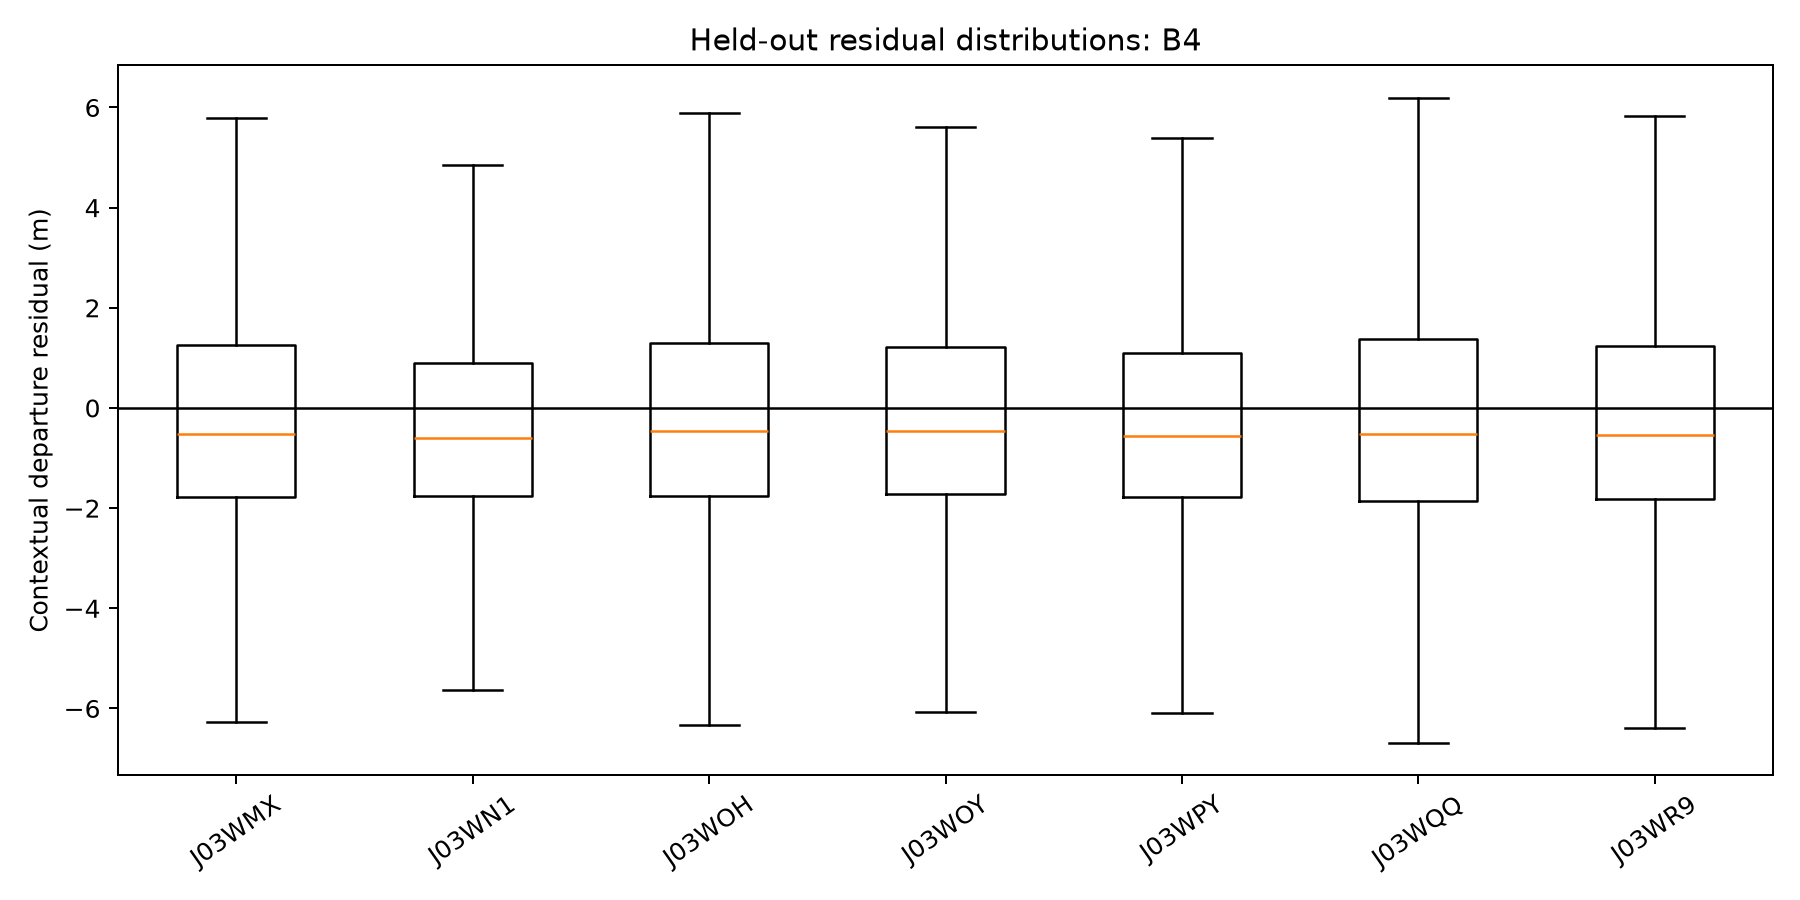

In [4]:
calibration = pd.read_csv(OUT / 'calibration.csv')
display(calibration[(calibration['history'].eq('2s')) & (calibration['model'].eq('B4')) & (calibration['bin'].astype(str).eq('ALL'))])
display(pd.read_csv(OUT / 'residual_correlations.csv').query("scope == 'overall'"))
display(Image(filename=str(FIG / 'observed_vs_predicted_best.png')))
display(Image(filename=str(FIG / 'residuals_by_match.png')))

## Frozen one-second sensitivity

,model,2s_median_MAE,1s_median_MAE
0,B0,2.665929,2.665929
1,B1,2.165298,2.088868
2,B2,2.128902,2.059663
3,B3,2.119231,2.053167
4,B4,2.113946,2.048269


,prior,current,median_relative_MAE_improvement,matches_improved,matches_worsened_10pct_or_more,materiality_pass
0,B0,B1,0.214602,7,0,True
1,B1,B2,0.017954,7,0,False
2,B2,B3,0.003302,7,0,False
3,B3,B4,0.002444,6,0,False


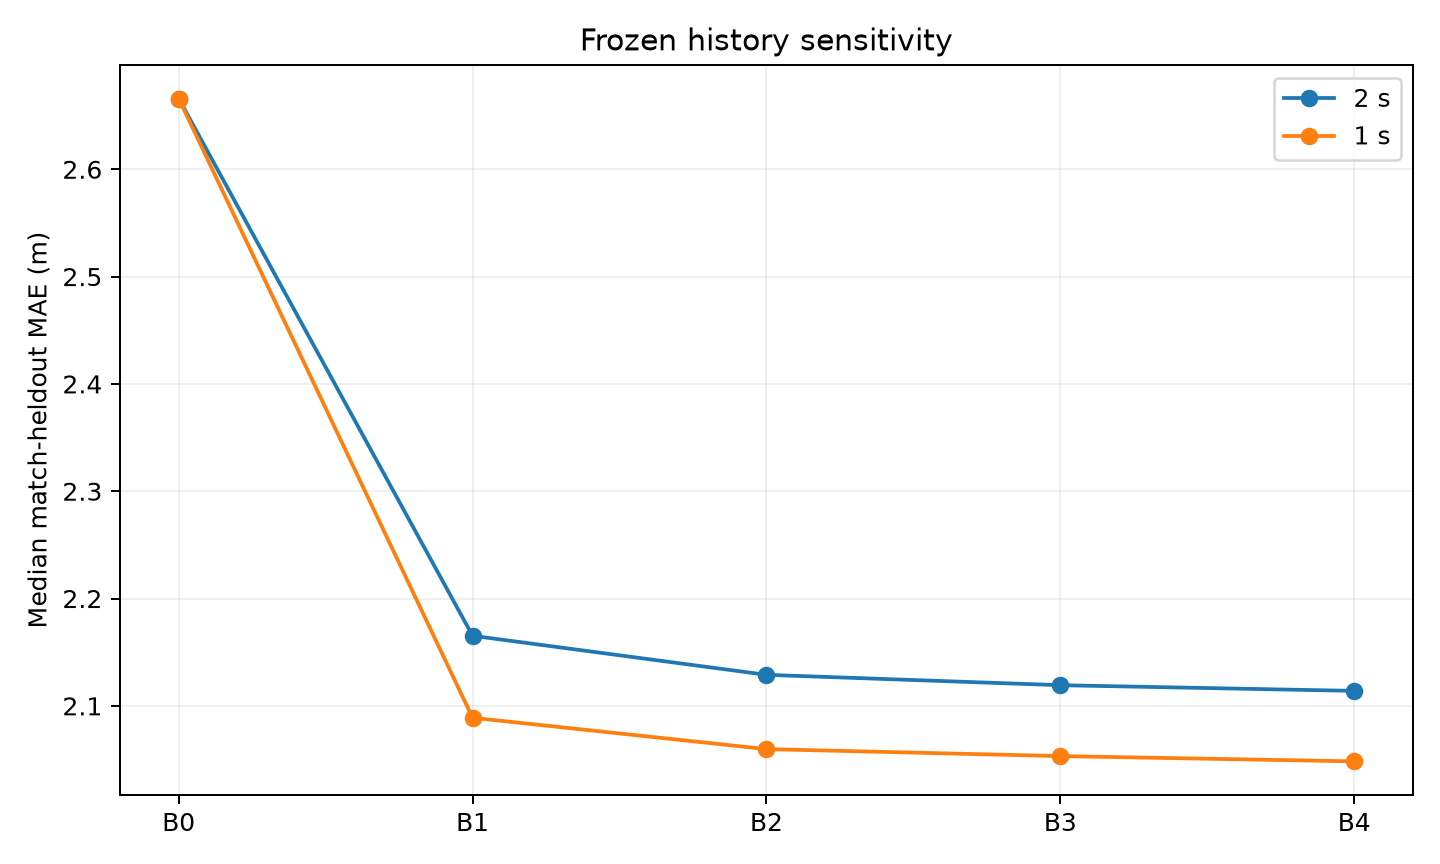

In [5]:
display(pd.read_csv(OUT / 'history_sensitivity.csv'))
display(pd.read_csv(OUT / 'sensitivity_adjacent_materiality.csv'))
display(Image(filename=str(FIG / 'history_sensitivity.png')))

## Interpretation boundary

The maximum supported claim is: **Future focal-relative path contains reproducibly predictable structure from pre-interval observable context.** Most useful information in this ladder was already in focal recent movement. Prediction is not causation, and the residual is not tactical response, tactical error, attacker effect, gravity, or value.